# 04 - Ringkasan Hasil

Tabel 3, plot komparatif F1, analisis segmentation failures, feature importance.

In [1]:
# ============================================================
# Setup cell - Kaggle Notebooks (Kaggle-only). Jalankan PALING ATAS.
# Cara attach dataset: panel kanan > + Add Data > cari
#   'fruit and vegetable disease healthy vs rotten' > Add.
# ============================================================
import os
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import sys
import shutil
import subprocess
from pathlib import Path

# 1. Clone repo dari GitHub (atau pull jika sudah ada di sesi ini)
REPO_URL = "https://github.com/faizhuda/pcd-kelompok-17.git"
PROJECT_DIR = Path("/kaggle/working/pcd-kelompok-17")
if not PROJECT_DIR.exists():
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(PROJECT_DIR)], check=True)
else:
    subprocess.run(["git", "-C", str(PROJECT_DIR), "pull", "--ff-only"], check=False)

# 2. Working directory ke root project + tambah ke sys.path
os.chdir(PROJECT_DIR)
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

# 3. Dependency inti SUDAH pre-installed di Kaggle -> tidak ada pip install.

# 4. Dataset gambar (read-only, hasil + Add Data)
# Auto-detect: Kaggle bisa mount di /kaggle/input/<slug> atau
# /kaggle/input/datasets/<user>/<slug> tergantung cara attach.
_DATASET_SLUG = 'fruit-and-vegetable-disease-healthy-vs-rotten'
_candidates = [
    Path('/kaggle/input') / _DATASET_SLUG,
    Path('/kaggle/input/datasets/muhammad0subhan') / _DATASET_SLUG,
]
RAW_DATA_DIR = next((p for p in _candidates if p.exists()), None)
if RAW_DATA_DIR is None:
    # Fallback: cari folder mana saja di /kaggle/input yang berisi gambar dataset
    for _p in Path('/kaggle/input').rglob(_DATASET_SLUG):
        if _p.is_dir():
            RAW_DATA_DIR = _p
            break
assert RAW_DATA_DIR is not None, "Dataset belum di-attach. + Add Data > cari dataset > Add."

# 5. Auto-restore hasil notebook sebelumnya (untuk notebook 03 & 04).
#    Attach output run lama via: + Add Data > Your Work / Dataset bersama.
def restore_previous_outputs():
    # Kaggle mounts notebook outputs di /kaggle/input/notebooks/<user>/<notebook>/
    # sehingga perlu rglob, bukan glob satu level.
    restored = []
    for repo in Path("/kaggle/input").rglob("pcd-kelompok-17"):
        if not repo.is_dir():
            continue
        for sub in ("results", "data/processed"):
            src_dir = repo / sub
            if src_dir.exists():
                shutil.copytree(src_dir, PROJECT_DIR / sub, dirs_exist_ok=True)
                restored.append(str(src_dir))
    return restored

restored = restore_previous_outputs()
print("Project :", PROJECT_DIR)
print("Dataset :", RAW_DATA_DIR)
print("Restore :", restored or "(mulai dari nol)")


Cloning into '/kaggle/working/pcd-kelompok-17'...


Project : /kaggle/working/pcd-kelompok-17
Dataset : /kaggle/input/datasets/muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten
Restore : ['/kaggle/input/notebooks/faiznaufalhuda/pcd-02-classical/pcd-kelompok-17/results', '/kaggle/input/notebooks/faiznaufalhuda/pcd-02-classical/pcd-kelompok-17/data/processed', '/kaggle/input/notebooks/faiznaufalhuda/pcd-03-cnn/pcd-kelompok-17/results', '/kaggle/input/notebooks/faiznaufalhuda/pcd-03-cnn/pcd-kelompok-17/data/processed']


In [2]:
import os
import sys
from pathlib import Path

# Setup cell sudah chdir ke PROJECT_DIR & menambah sys.path (Kaggle-only).
ROOT = Path("/kaggle/working/pcd-kelompok-17")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.evaluate import aggregate_feature_importance, plot_feature_importance, print_summary_table
from src.utils import get_project_paths, read_best_enhancement

paths = get_project_paths()
metrics_dir = paths["metrics"]


## Tabel 3 - Ringkasan Semua Skenario

In [3]:
summary = print_summary_table(metrics_dir)
summary


 scenario_id restoration enhancement  segmentation      features       model  f1_weighted  accuracy  inference_time_ms_per_image
           1        none        none         False color+texture         SVM     0.970402  0.970414                     1.785732
           2         ssr        none         False color+texture         SVM     0.947660  0.947656                     2.229449
           3         ssr       clahe         False color+texture         SVM     0.956072  0.956076                     2.112423
           4         ssr       gamma         False color+texture         SVM     0.949250  0.949249                     2.121267
           5         ssr       clahe          True           all         SVM     0.952891  0.952890                     2.293156
           6         ssr       clahe          True         color         SVM     0.935588  0.935594                     2.355147
           7         ssr       clahe          True       texture         SVM     0.810132  0.8099

,scenario_id,restoration,enhancement,segmentation,features,model,accuracy,precision_weighted,recall_weighted,f1_weighted,inference_time_ms_per_image,n_test_samples
0,1,none,none,False,color+texture,SVM,0.970414,0.970469,0.970414,0.970402,1.785732,4394
1,2,ssr,none,False,color+texture,SVM,0.947656,0.947668,0.947656,0.947660,2.229449,4394
2,3,ssr,clahe,False,color+texture,SVM,0.956076,0.956073,0.956076,0.956072,2.112423,4394
3,4,ssr,gamma,False,color+texture,SVM,0.949249,0.949250,0.949249,0.949250,2.121267,4394
4,5,ssr,clahe,True,all,SVM,0.952890,0.952892,0.952890,0.952891,2.293156,4394
5,6,ssr,clahe,True,color,SVM,0.935594,0.935586,0.935594,0.935588,2.355147,4394
6,7,ssr,clahe,True,texture,SVM,0.809968,0.811692,0.809968,0.810132,0.681285,4394
7,8,ssr,clahe,True,shape,SVM,0.616523,0.628179,0.616523,0.595791,0.820781,4394
8,9,ssr,clahe,True,all,RF,0.937870,0.937863,0.937870,0.937864,0.012962,4394
9,10,ssr,clahe,True,cnn,MobileNetV2,0.982931,0.982961,0.982931,0.982935,28.905651,4394


## Plot Komparatif F1-Score

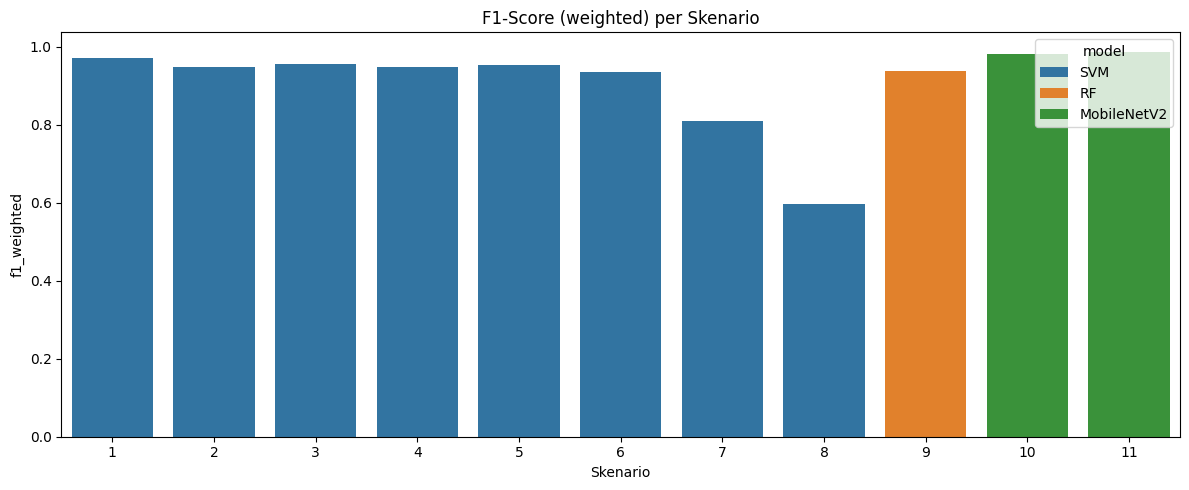

In [4]:
if not summary.empty:
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=summary, x="scenario_id", y="f1_weighted", hue="model", ax=ax)
    ax.set_title("F1-Score (weighted) per Skenario")
    ax.set_xlabel("Skenario")
    plt.tight_layout()
    plt.savefig(paths["figures"] / "f1_comparison.png", dpi=150)
    plt.show()


## Enhancement Terpilih (E*)

In [5]:
print(f"Best enhancement: {read_best_enhancement(metrics_dir)}")


Best enhancement: clahe


## Segmentation Failures

In [6]:
fail_path = metrics_dir / "segmentation_failures.csv"
if fail_path.exists():
    fails = pd.read_csv(fail_path)
    display(fails.groupby("commodity").size().sort_values(ascending=False).head(10))
else:
    print("Belum ada log segmentasi. Jalankan skenario dengan segmentasi aktif.")


Belum ada log segmentasi. Jalankan skenario dengan segmentasi aktif.


## Uji Signifikansi McNemar

In [7]:
sig_path = metrics_dir / "significance_tests.csv"
if sig_path.exists():
    display(pd.read_csv(sig_path))
else:
    print("Jalankan notebook 02 dan 03 untuk uji McNemar.")


,comparison,model_a,model_b,statistic,p_value,conclusion
0,S2 vs S1 (SSR),S2,S1,44.550000,2.479435e-11,signifikan
1,E*(clahe) vs S2,S3,S2,8.697987,3.185617e-03,signifikan
2,S5 vs E*-noseg (segmentasi),S5,S3,1.564815,2.109616e-01,tidak signifikan
3,S10 vs S5 (CNN vs SVM),S10,S5,70.331967,5.011891e-17,signifikan
4,S11 vs S1 (CNN-raw vs SVM-raw),S11,S1,37.751634,8.034939e-10,signifikan
5,S10 vs S11 (full vs raw CNN),S10,S11,5.959459,1.463853e-02,signifikan


## Feature Importance (Skenario 9 - RF)

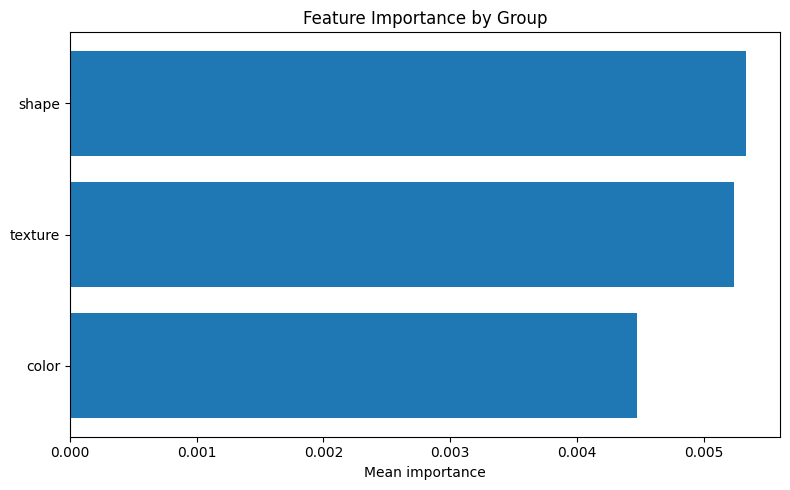

In [8]:
import joblib

rf_path = paths["models"] / "rf_scenario_09.pkl"
if rf_path.exists():
    rf = joblib.load(rf_path)
    from src.features import get_feature_group_names
    names = get_feature_group_names("all", segmented=True)
    if len(names) != len(rf.feature_importances_):
        names = [f"f{i}" for i in range(len(rf.feature_importances_))]
    labels, vals = aggregate_feature_importance(rf.feature_importances_, names)
    plot_feature_importance(vals, labels, save_path=paths["figures"] / "feature_importance_s09.png")
    plt.show()
else:
    print("Model RF S9 belum tersedia. Jalankan notebook 02 terlebih dahulu.")


## Inference Time Comparison

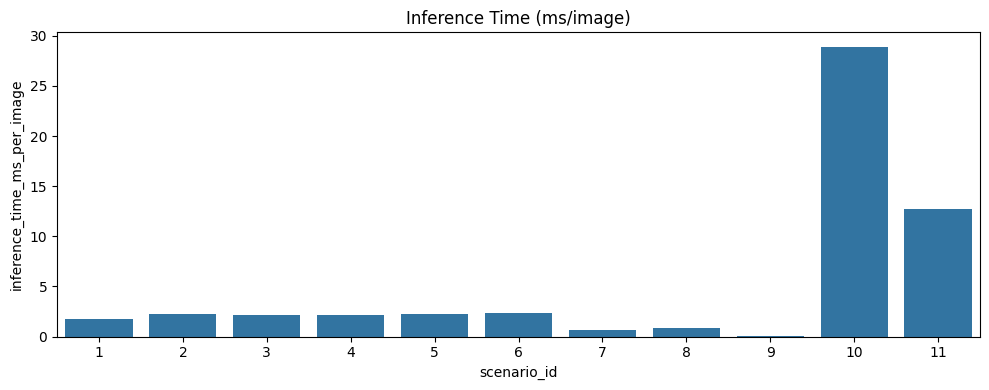

In [9]:
if not summary.empty and "inference_time_ms_per_image" in summary.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(data=summary, x="scenario_id", y="inference_time_ms_per_image", ax=ax)
    ax.set_title("Inference Time (ms/image)")
    plt.tight_layout()
    plt.show()


## Kelemahan Sistem & Limitasi

Bagian ini wajib dibahas dalam laporan (rubrik #9). Bukan kegagalan sistem,
melainkan batas kebenaran klaim yang jujur harus diakui.

### 1. Single split, satu seed
Seluruh angka F1/akurasi bertumpu pada **satu pembagian data acak** (SEED=42,
70/15/15). Tidak ada repeated runs atau confidence interval. Akibatnya:
- Perbedaan F1 kecil antar skenario (mis. 0.92 vs 0.89) bisa jadi noise split.
- McNemar membantu di level prediksi per-sampel, tapi tidak menangkap varians
  yang muncul kalau seed diganti.
- **Saran pengembangan**: k-fold lintas seed, atau setidaknya 3 seed berbeda.

### 2. Risiko leakage near-duplicate
Dataset Kaggle buah/sayur sering memuat banyak foto dari **objek fisik yang sama**
dalam kondisi pencahayaan/sudut berbeda. Split acak per-citra bisa menaruh
near-duplicate di train **dan** test sekaligus, menggelembungkan semua angka.
- Tidak ada deteksi duplikat yang dilakukan (membutuhkan image hashing atau
  perceptual similarity).
- Angka performa yang sangat tinggi (>95% F1) harus dibaca dengan hati-hati
  karena kemungkinan mengandung kontaminasi ini.
- **Saran pengembangan**: deduplikasi dengan pHash sebelum split.

### 3. Desain ladder, bukan factorial
Setiap skenario mengubah satu variabel terhadap sibling-nya (*one-factor-at-a-time*).
Ini memudahkan interpretasi tapi **tidak bisa menangkap interaksi antar faktor**:
- Belum diuji: apakah CLAHE efektif *tanpa* SSR, atau manfaatnya bergantung SSR?
- Belum diuji: apakah segmentasi membantu pada komoditas tertentu tapi menyakiti
  yang lain?
- **Saran pengembangan**: desain 2×2 factorial (SSR on/off × segmentasi on/off)
  untuk melihat interaksi.

### 4. Segmentasi berbasis threshold (Otsu) tanpa learning
Metode segmentasi — Otsu pada kanal S (HSV) + grayscale + morfologi — sederhana
dan cepat, tapi gagal pada buah/sayur gelap berlatar belakang serupa (tercatat
di `segmentation_failures.csv`). Fallback (gambar penuh) dipakai saat foreground
<5%, artinya fitur segmentasi kehilangan maknanya pada sebagian sampel.


## Per-Commodity Performance Comparison

,commodity,samples,f1_s5,f1_s10
10,Pomegranate,60,1.000000,1.000000
6,Guava,60,0.949875,1.000000
1,Banana,720,0.981931,0.997222
12,Strawberry,480,0.987500,0.995833
0,Apple,804,0.968909,0.988810
8,Mango,609,0.960545,0.988504
9,Orange,640,0.960939,0.985938
5,Grape,60,0.899889,0.983329
2,Bellpepper,181,0.855301,0.972372
13,Tomato,180,0.899889,0.966650


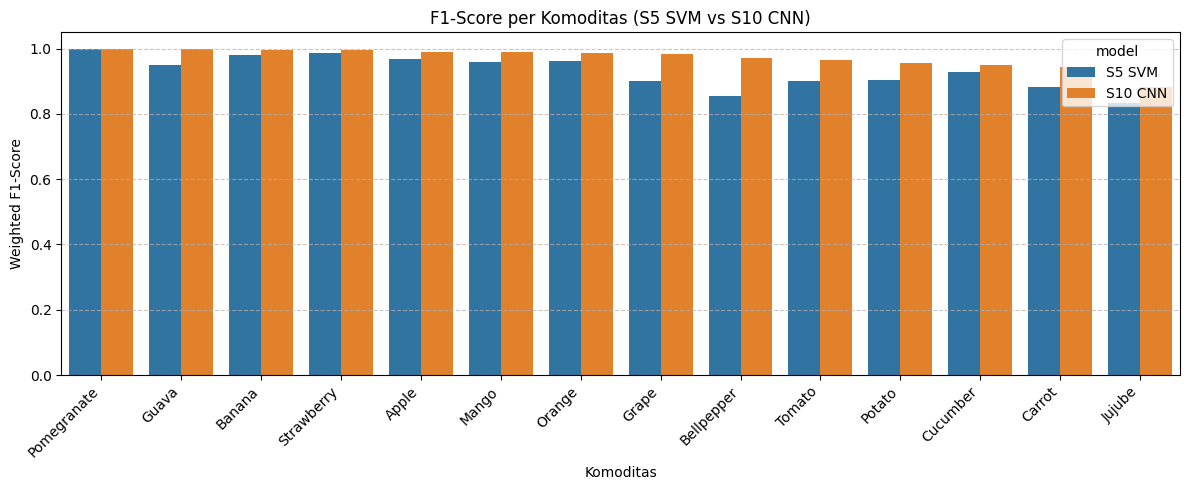

In [10]:
s5_pred_path = metrics_dir / "predictions_s5.csv"
s10_pred_path = metrics_dir / "predictions_s10.csv"

if s5_pred_path.exists() and s10_pred_path.exists():
    from sklearn.metrics import f1_score
    s5_preds = pd.read_csv(s5_pred_path)
    s10_preds = pd.read_csv(s10_pred_path)
    label_map = {"fresh": 0, "rotten": 1}
    s5_preds["true_encoded"] = s5_preds["label"].map(label_map)
    s10_preds["true_encoded"] = s10_preds["label"].map(label_map)
    s5_comm = []
    for comm, group in s5_preds.groupby("commodity"):
        f1 = f1_score(group["true_encoded"], group["pred"], average="weighted", zero_division=0)
        s5_comm.append({"commodity": comm, "samples": len(group), "f1_s5": f1})
    df_s5_comm = pd.DataFrame(s5_comm)
    s10_comm = []
    for comm, group in s10_preds.groupby("commodity"):
        f1 = f1_score(group["true_encoded"], group["pred"], average="weighted", zero_division=0)
        s10_comm.append({"commodity": comm, "f1_s10": f1})
    df_s10_comm = pd.DataFrame(s10_comm)
    df_compare = pd.merge(df_s5_comm, df_s10_comm, on="commodity").sort_values("f1_s10", ascending=False)
    display(df_compare)
    df_melted = df_compare.melt(id_vars=["commodity", "samples"], value_vars=["f1_s5", "f1_s10"],
                                var_name="model", value_name="f1_score")
    df_melted["model"] = df_melted["model"].map({"f1_s5": "S5 SVM", "f1_s10": "S10 CNN"})
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=df_melted, x="commodity", y="f1_score", hue="model", ax=ax)
    ax.set_title("F1-Score per Komoditas (S5 SVM vs S10 CNN)")
    ax.set_ylabel("Weighted F1-Score")
    ax.set_xlabel("Komoditas")
    ax.set_ylim(0, 1.05)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(paths["figures"] / "commodity_comparison.png", dpi=150)
    plt.show()
else:
    print("Prediksi S5 atau S10 belum lengkap. Lewati perbandingan komoditas.")
